# Feature Importance

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import KFold, GridSearchCV

# Make plots render nicely
shap.initjs()

## 2. Load Data

In [2]:
train_df = pd.read_csv("./data/flood_train_scaled.csv")
test_df = pd.read_csv("./data/flood_test_scaled.csv")

TARGET = "FloodProbability"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 20)
Test shape: (10000, 20)


## 3. Define SHAP Analysis Function

We use SHapley Additive exPlanations (SHAP) values to explore feature importance. SHAP values are a feature attribution method that assigns each input variable a numerical contribution to an individual prediction. These contributions represent how much each feature changes the prediction relative to a baseline expectation. Positive values indicate that a feature increases the predicted outcome, while negative values indicate a decrease. Aggregating these values across all observations provides a consistent measure of global feature importance, while still preserving detailed local explanations.

This approach enables both global and local interpretability of complex machine learning models. At a global level, it identifies which factors most strongly influence predictions overall. At a local level, it explains why a specific prediction is high or low by breaking it down into feature-level contributions. This dual capability is particularly important in high-stakes predictive settings, where understanding the reasoning behind individual predictions is as important as overall model accuracy. It also provides a mechanism to validate whether the model is learning meaningful relationships consistent with real-world environmental and infrastructural behavior, rather than relying on spurious correlations.

To make the code cleaner and more efficient, we defined a function ("shap_analysis") that runs the analysis. The function takes the model, model name, training set, and test features, and returns the following:
- Top Features Table: The top features table ranks the top 10 features based on their mean absolute SHAP values, which quantify the average magnitude of each feature’s contribution to the model’s predictions across all observations. Higher values indicate that a feature consistently has a stronger influence on the output, regardless of whether that influence is positive or negative. This produces a global ranking of feature importance grounded in how much each variable affects model behavior on average.

- Bar Plot: The bar plot visualizes global feature importance using the mean absolute SHAP value for each feature. It ranks variables by the average magnitude of their contribution to model predictions, without distinguishing whether the effect increases or decreases predicted outcomes. It is designed to show which features most strongly influence the model overall.

- Beeswarm Plot: The beeswarm plot shows the distribution of SHAP values for each feature across all observations. Each point represents a single case, with horizontal position indicating the feature’s impact on the prediction and color representing the feature’s value from low to high. This allows simultaneous observation of both the direction and variability of each feature’s effect on the model output.

In [3]:
def shap_analysis(
    model=None, model_name=None, X_train=X_train, y_train=y_train, X_test=X_test
):
    """This function performs the SHAP analysis. It takes in the model, model name,
    training set (split into feature and outcome sets), and the test features.
    From there, the function trains the model, computes the SHAP values, and displays the
    reasons via a feature-ranking table, bar plot, and beeswarm plot."""
    # Train model
    model.fit(X_train, y_train)

    # Compute SHAP Values
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    # Ranked Feature Importance Table
    shap_importance = pd.DataFrame(
        {
            "Feature": X_test.columns,
            "Importance": np.abs(shap_values.values).mean(axis=0),
        }
    ).sort_values(by="Importance", ascending=False)

    print("Top 10 SHAP Features:")
    display(shap_importance.head(10))

    # Plot Bar Plot
    ax = shap.plots.bar(shap_values, max_display=20, show=False)

    ax.set_xlabel("Mean Absolute SHAP Value")
    ax.set_title(f"Mean Absolute SHAP Bar Plot ({model_name})", x=0.25, fontsize=18)

    plt.tight_layout()
    plt.show()

    # Plot Beeswarm Plot
    ax2 = shap.plots.beeswarm(shap_values, max_display=20, show=False)

    ax2.set_title(f"SHAP Beeswarm Plot ({model_name})", x=0.25, fontsize=20)

    plt.tight_layout()
    plt.show()

## 4. Multiple Linear Regression SHAP Analysis

Top 10 SHAP Features:


,Feature,Importance
19,PoliticalFactors,0.010392
10,IneffectiveDisasterPreparedness,0.010159
5,ClimateChange,0.010030
18,InadequatePlanning,0.009758
2,RiverManagement,0.008163
6,DamsQuality,0.007980
15,DeterioratingInfrastructure,0.007947
11,DrainageSystems,0.007728
4,Urbanization,0.005545
16,PopulationScore,0.005507


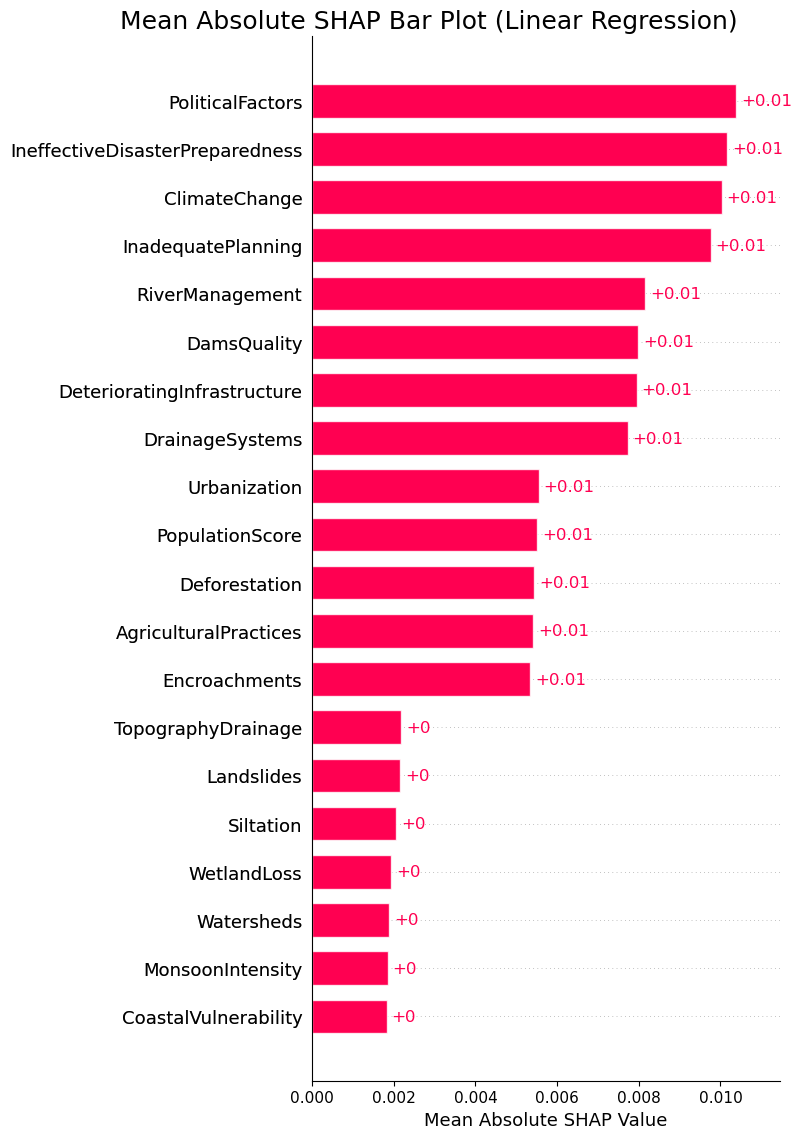

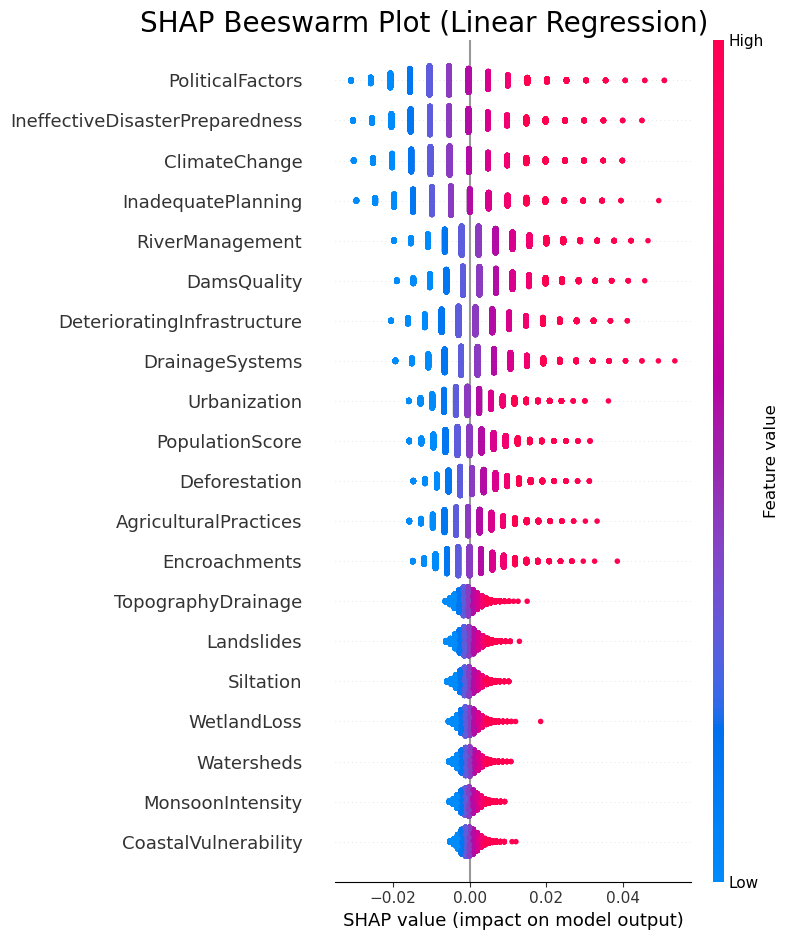

In [4]:
# Initialize linear model
lin_model = LinearRegression()

# Perform SHAP analysis
shap_analysis(model=lin_model, model_name="Linear Regression")

The SHAP analysis for the linear regression model shows a relatively flat but ordered importance structure, with mean absolute SHAP values, which represent the average magnitude of each feature’s contribution to the prediction across all observations, clustered between 0.008 and 0.010 for the top variables. Political factors contribute the most with a value of 0.0104, followed closely by ineffective disaster preparedness at 0.0102, climate change at 0.0100, and inadequate planning at 0.0098. The small spread across these top variables indicates that the model distributes importance across several correlated systemic factors rather than relying on a single dominant predictor.

A second tier, including river management, dams quality, deteriorating infrastructure, and drainage system capacity, shows slightly lower mean absolute SHAP values ranging from 0.0077 to 0.0082, forming a smooth importance gradient. In contrast, lower-ranked variables such as urbanization and population density drop to 0.0055, while the remaining features, including monsoon intensity, coastal vulnerability, and topography and drainage characteristics, fall at or below 0.002, indicating minimal marginal impact on predictions.

The beeswarm plot displays individual SHAP values, which measure how much a specific feature value shifts a single prediction away from the model’s average predicted flood probability. These values show consistent directional effects, where higher feature values increase predicted flood probability. The most important features exhibit the widest SHAP ranges, from −0.02 to 0.05, indicating that they can meaningfully increase or decrease predictions depending on their values. Lower-importance variables exhibit tightly compressed distributions near zero, reinforcing their limited influence. The overall linear and symmetric structure of the SHAP distributions reflects stable additive effects with little evidence of interaction or nonlinear behavior, suggesting the model captures broad trends but may underrepresent more complex or extreme dynamics.

## 5. XGBoost SHAP Analysis

100%|===================| 9959/10000 [01:58<00:00]        

Top 10 SHAP Features:


,Feature,Importance
19,PoliticalFactors,0.010420
18,InadequatePlanning,0.010371
10,IneffectiveDisasterPreparedness,0.010304
5,ClimateChange,0.009690
2,RiverManagement,0.008513
6,DamsQuality,0.008335
15,DeterioratingInfrastructure,0.008214
11,DrainageSystems,0.007916
8,AgriculturalPractices,0.005810
16,PopulationScore,0.005330


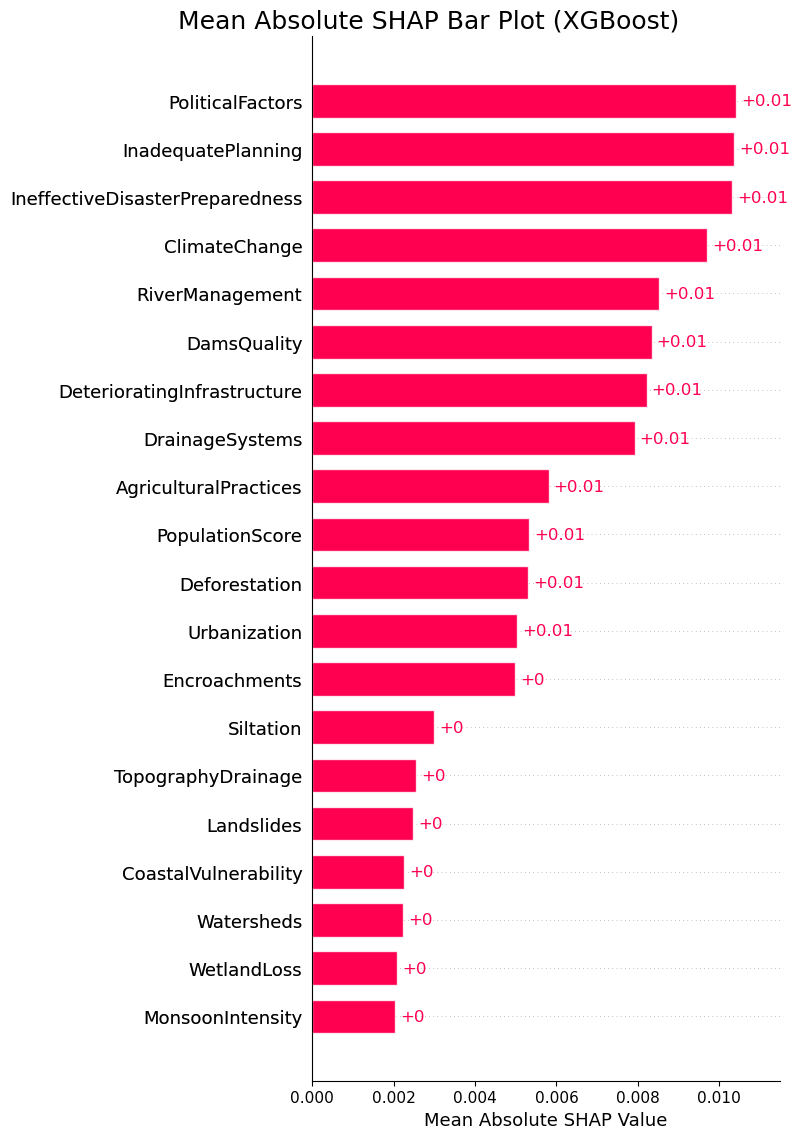

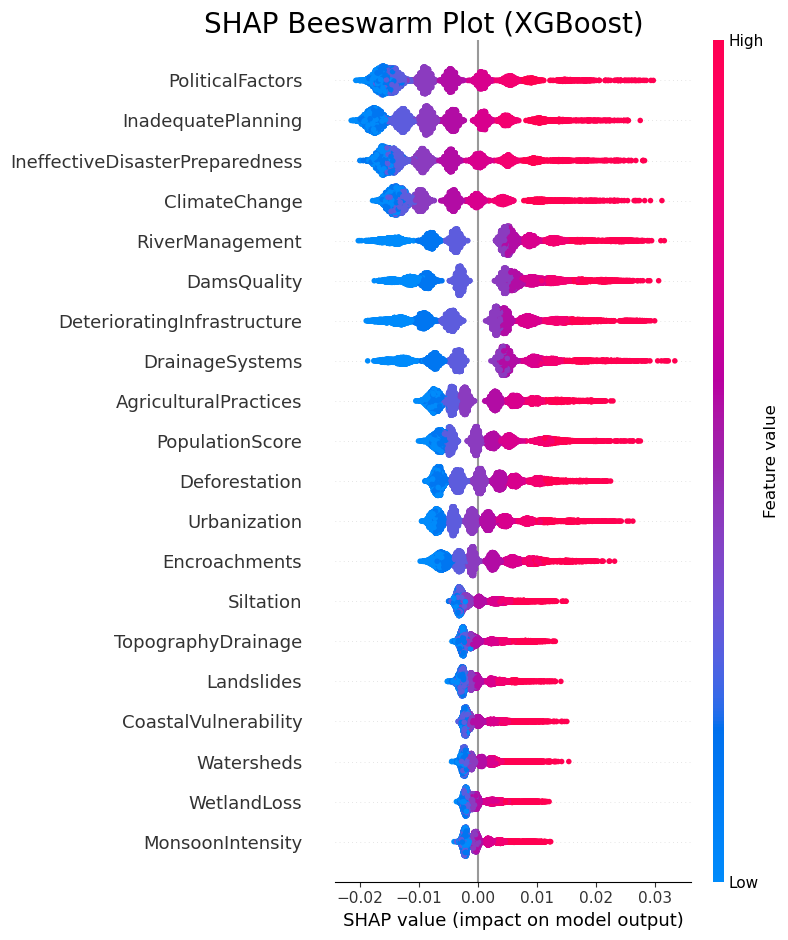

In [5]:
# Initialize XGBoost model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

# Perform SHAP analysis
shap_analysis(model=xgb_model, model_name="XGBoost")

The SHAP analysis for XGBoost shows that the highest contributions are tightly clustered, with climate change at a mean absolute SHAP value of 0.0104, followed by ineffective disaster preparedness at 0.01030 and inadequate planning at 0.01037. Political factors contribute 0.00969, while river management and dams quality contribute 0.00851 and 0.00834. Other infrastructure-related variables, including deteriorating infrastructure and drainage systems, fall within 0.0079 to 0.0082. This narrow range indicates that the model distributes importance across multiple correlated drivers rather than relying on a single dominant feature, consistent with a multicollinearity or interaction-driven structure.

The beeswarm plot shows SHAP values with wide and asymmetric distributions for the most important features, typically ranging from −0.02 to 0.03. Lower values of governance effectiveness, planning quality, and disaster preparedness correspond to higher SHAP values for flood probability, while higher values reduce predicted risk. Climate change exhibits a similar pattern with a right-skewed distribution, indicating larger SHAP values at higher levels of climate stress. Infrastructure-related variables such as river management, dams quality, deteriorating infrastructure, and drainage systems show moderate SHAP value dispersion, generally between −0.015 and 0.02, with consistent directional effects. In contrast, lower-ranked variables such as siltation, topography and drainage characteristics, coastal vulnerability, wetland loss, and monsoon intensity are tightly clustered near zero, typically within −0.005 to 0.01 in SHAP values, indicating limited marginal impact. The low importance and narrow spread of monsoon intensity suggest its effect is either indirectly captured through correlated variables or limited in explanatory power within the dataset.

Compared to the linear regression model, the XGBoost results preserve a similar feature ranking based on mean absolute SHAP values but show greater dispersion and asymmetry in SHAP values. This indicates that XGBoost captures nonlinear and heterogeneous effects that the linear model cannot, while the consistency in the ranking of key drivers across both models suggests that the underlying relationships are stable rather than model-specific.

## 6. Sparse-Optimal Decision Trees SHAP Analysis

Best Sparse Optimal Tree Params: {'ccp_alpha': np.float64(0.0), 'max_depth': 5, 'min_samples_leaf': 25}
Top 10 SHAP Features:


,Feature,Importance
19,PoliticalFactors,0.008711
10,IneffectiveDisasterPreparedness,0.006492
16,PopulationScore,0.006130
15,DeterioratingInfrastructure,0.003614
3,Deforestation,0.003035
6,DamsQuality,0.002999
2,RiverManagement,0.002722
5,ClimateChange,0.002600
8,AgriculturalPractices,0.002175
18,InadequatePlanning,0.002041


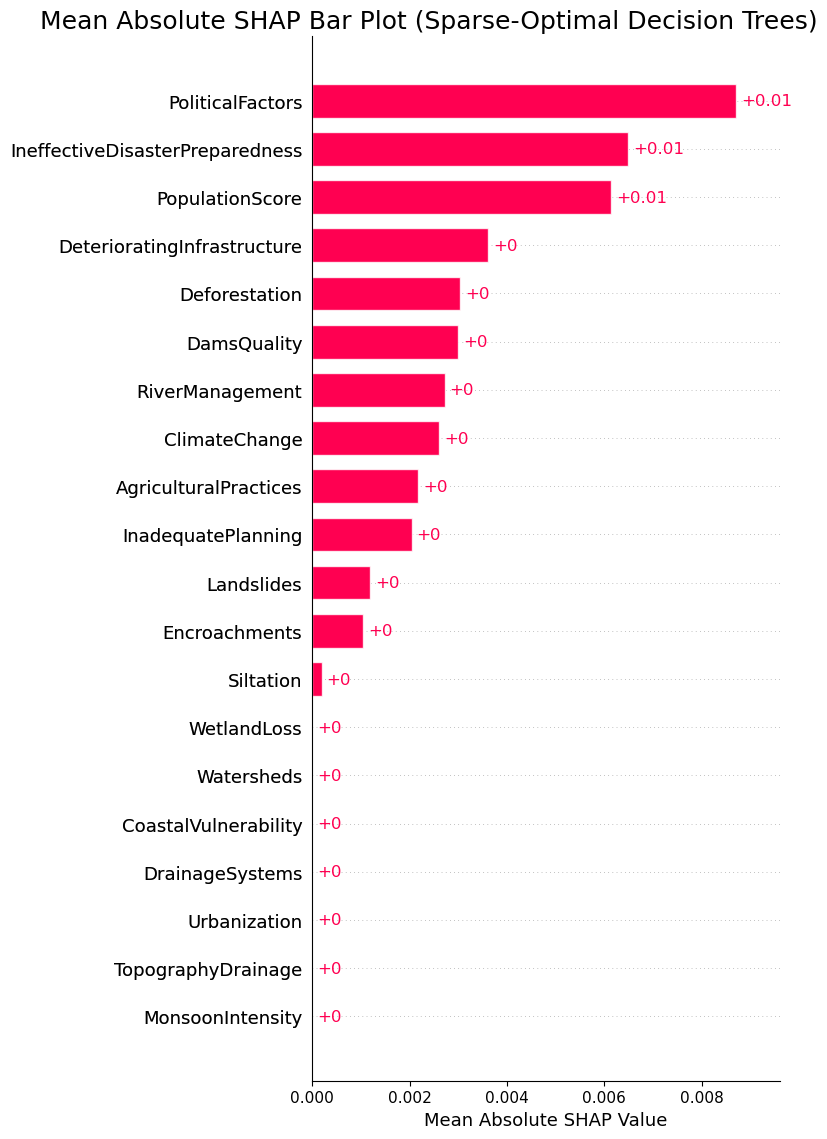

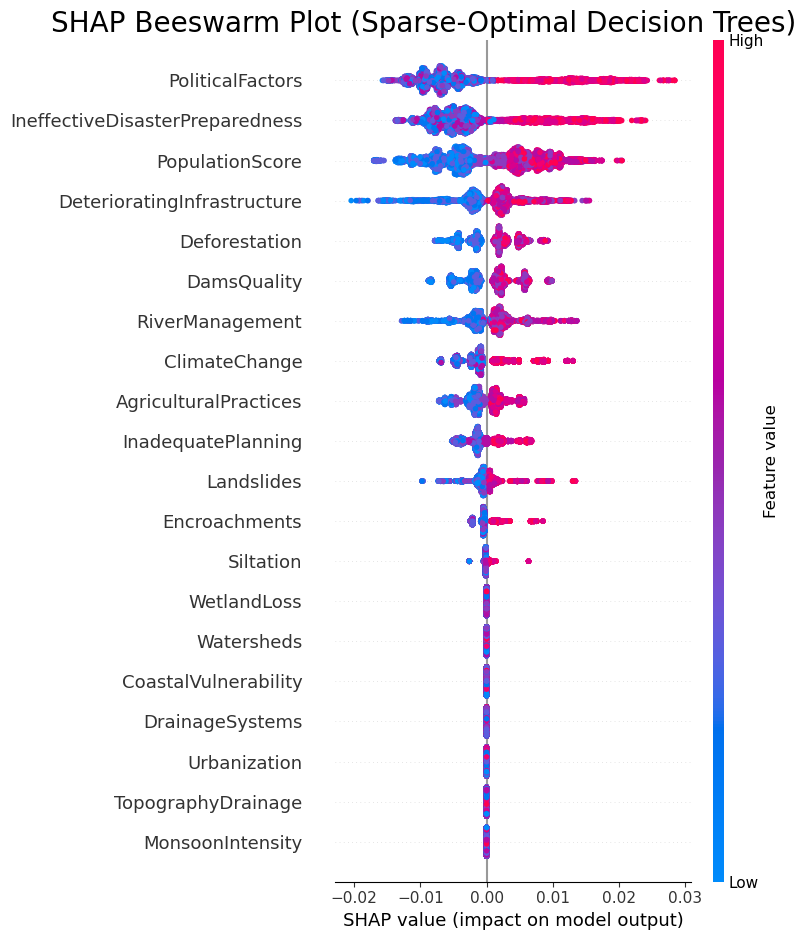

In [6]:
# Initialize K-Fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Tune hyperparameters (using the grid search approach) to select the best model
base_tree_sodt = DecisionTreeRegressor(random_state=42)

path = base_tree_sodt.cost_complexity_pruning_path(X_train, y_train)
candidate_alphas = np.unique(np.round(path.ccp_alphas, 6))
candidate_alphas = candidate_alphas[candidate_alphas >= 0]

param_grid_sodt = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [25, 50, 100],
    "ccp_alpha": candidate_alphas,
}

sodt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_sodt,
    scoring="r2",
    cv=cv,
    n_jobs=1,
    refit=True,
)

sodt_grid.fit(X_train, y_train)

# Store best model
tree_model_sodt = sodt_grid.best_estimator_
print("Best Sparse Optimal Tree Params:", sodt_grid.best_params_)

# Perform SHAP analysis
shap_analysis(model=tree_model_sodt, model_name="Sparse-Optimal Decision Trees")

The SHAP results for the Sparse Optimal Decision Trees model indicate a concentrated importance structure, where a small set of features accounts for a disproportionate share of the model’s explanatory power. Political factors have the highest mean absolute SHAP value at 0.0087, followed by ineffective disaster preparedness at 0.0065 and population score at 0.0061. After these top three variables, there is a noticeable drop in magnitude, with deteriorating infrastructure at 0.0036 and both deforestation and dams quality at 0.0030. River management and climate change follow at 0.0027 and 0.0026, while agricultural practices and inadequate planning contribute 0.0022 and 0.0020. The remaining variables have mean absolute SHAP values close to zero, indicating minimal marginal contribution. This sharper decline after the leading features suggests that the model is prioritizing a more compact subset of predictors rather than distributing importance broadly across correlated variables.

The SHAP beeswarm plot highlights both the directionality and dispersion of these effects. The highest-ranked features show the widest spread, with SHAP values typically ranging from negative 0.02 to positive 0.03, indicating substantial influence on individual predictions. These variables exhibit consistent monotonic behavior, where higher values of governance risk, weaker preparedness, and greater population exposure shift predictions toward higher flood probability. Infrastructure-related variables such as deteriorating infrastructure, dams quality, and river management display moderate dispersion, generally between negative 0.01 and positive 0.02, with some asymmetry that suggests conditional effects depending on feature interactions. Climate change shows a right-skewed distribution, with larger positive SHAP values at higher levels, indicating stronger marginal effects under more extreme conditions. In contrast, variables such as monsoon intensity, watershed characteristics, coastal vulnerability, and wetland loss are tightly clustered around zero, typically within negative 0.005 to positive 0.005, showing very limited variation in their contribution across observations. This compression suggests either low standalone explanatory power or that their effects are subsumed through interactions with higher-ranked variables.

When compared to the linear regression and XGBoost models, the Sparse Optimal Decision Trees results maintain consistent identification of the primary drivers but differ in how importance is allocated and expressed. The linear regression model shows a flatter importance distribution, with top SHAP values around 0.010 and a gradual decline across features, reflecting a fully additive structure. XGBoost also reports top values near 0.010 but exhibits greater dispersion in the beeswarm plot, with SHAP values frequently spanning negative 0.02 to positive 0.03 and showing more pronounced asymmetry, consistent with nonlinear and interaction effects. The Sparse Optimal Decision Trees model, by contrast, introduces a steeper importance gradient and more compact SHAP distributions, indicating a more constrained representation of feature effects. Despite these structural differences, the alignment in top-ranked variables across all three models suggests that the underlying signal is stable and not model-specific.